# Avance 4. Modelos alternativos

El objetivo de este notebook es construir múltiples modelos (individuales, no ensambles) relevantes para realizar el pronóstico y evaluar su desempeño. Diferentes algoritmos pueden comportarse de manera óptima en diferentes tipos de datos o tareas. La construcción de modelos alternativos permite explorar y evaluar cuál de ellos proporciona el mejor rendimiento para un problema particular. Para esto será necesario:

* Explorar una gama diversa de técnicas y enfoques con el fin de identificar el de mejor desempeño en el conjunto de datos en cuestión.

* Encontrar la configuración óptima que maximiza el rendimiento del modelo en una tarea específica.

## 1. Librerías y Carga de Datos.

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
# Control de visualización: desactivar Plotly para generar gráficas con Matplotlib/Seaborn en este notebook.
USE_PLOTLY = True
# Nota: Plotly puede habilitarse para uso local cambiando a True si se desea interactividad.

### 1.1. Librerías

In [2]:
import sys
sys.path.append('../../')
import src.utils.helpers as func
import src.evaluation.metrics as meval
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from src.visualization import tsa_plots as tsp
from src.evaluation.interpretability import get_xbg_feature_importance
from src.evaluation.plots import plot_last_year, plot_residuals_distribution, plot_forecast

In [3]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import prince as pr
import plotly.express as px
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

### 1.2. Carga de Datos

In [4]:
# Usar df_log como dataset base para estos modelos
# path = r'C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_log.parquet'
path = '../../data/processed/df_log.parquet'

# Cargar datos (sin mostrar información para reducir salida de notebook)
df_log = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_log.parquet
Datos cargados exitosamente.


1.3 Argumentos Comunes para Graficar

In [5]:
# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

## 2. Modelos clásicos

### 2.1. Baseline: Holt-Winters
* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [6]:
# índice temporal
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')
scaled_method = 'log'
train, test = func.split_series(data, train_size=0.8)
train_org = func.get_original_scale_dataframe(train, method=scaled_method)
test_org = func.get_original_scale_dataframe(test, method=scaled_method)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se ajusta el modelo de suavizamiento exponencial doble utilizando únicamente el conjunto de entrenamiento.

In [7]:
model_triple = ExponentialSmoothing(
    train, 
    seasonal_periods=52, 
    trend='mul', 
    seasonal='add')

model_triple_fit = model_triple.fit()

* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [8]:
forecast_triple = model_triple_fit.forecast(115)

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [9]:
method = 'log'

df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(model_triple_fit.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_triple, method=method)

#### 2.1.1. Evaluación del modelo

##### 2.1.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [10]:
model_metrics = meval.evaluate_model_performance(train,test,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.111671 │
├───────────┼──────────┤
│ RMSE      │ 0.225802 │
├───────────┼──────────┤
│ MAPE      │ 0.016145 │
╘═══════════╧══════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 0.132012  │
├───────────┼───────────┤
│ RMSE      │ 0.188655  │
├───────────┼───────────┤
│ MAPE      │ 0.0169364 │
╘═══════════╧═══════════╛


La evaluación del modelo **Holt-Winters** de suavizado exponencial revela un desempeño predictivo sólido y consistente. En el **conjunto de Entrenamiento**, el modelo alcanza un **Error Absoluto Medio ($\text{MAE}$) de $0.111671$**, un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $0.225802$** y un **Error Porcentual Absoluto Medio ($\text{MAPE}$) de $1.61\%$**. Al ser evaluado en el **conjunto de Prueba (Test)**, el $\text{MAE}$ experimenta un ligero incremento a $0.132012$, y el $\text{MAPE}$ se mantiene estable en $1.69\%$, indicando que el modelo **generaliza eficientemente** la dinámica temporal con un **error porcentual muy bajo** y aceptable para la toma de decisiones. No obstante, el $\text{RMSE}$ **disminuye** a $0.188655$ en la prueba, sugiriendo que, si bien el error promedio absoluto aumenta ligeramente, la **magnitud de los errores de predicción más grandes** (penalizados por el $\text{RMSE}$) fue **menor** en el periodo de prueba, lo que en conjunto valida la **robustez y la precisión** del modelo Holt-Winters para capturar la tendencia y la estacionalidad de la serie.

##### 2.1.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

In [11]:
plot_residuals_distribution(train,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

En el **conjunto de Entrenamiento**, el histograma de errores se concentra fuertemente en torno a cero, y el gráfico de **Valores Reales vs Predicciones** muestra que los puntos de predicción (naranja) se alinean estrechamente con la **recta de $45^{\circ}$** (línea discontinua), indicando que el modelo replica con alta precisión los datos históricos. En el **conjunto de Prueba**, el histograma de errores sigue manteniendo su centro alrededor de cero, y aunque los puntos en el gráfico de **Valores Reales vs Predicciones** presentan una **mayor dispersión** alrededor de la línea de $45^{\circ}$ en comparación con el entrenamiento, esta **variabilidad es esperable** en datos fuera de muestra y confirma que el modelo no presenta un sesgo sistemático (los errores son aproximadamente simétricos a cero), lo que valida su **capacidad para generar pronósticos imparciales** de los casos semanales de depresión.

#### 2.1.2. Visualización de resultados

##### 2.1.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [12]:

# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformacion'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

Las gráficas del **Modelo Holt-Winters/Doble Suavizado Exponencial** en su escala original (inferior) y en la escala logarítmica (superior) evidencia su capacidad para modelar la tendencia y estacionalidad de la serie de casos de depresión. En la **escala original**, la **Serie Ajustada** (rojo) sigue fielmente las fluctuaciones de la **Serie Original** (azul) en el periodo de entrenamiento, y la **Serie Pronosticada** (verde) proyecta de manera adecuada la **tendencia ascendente reciente** y la estacionalidad futura, aunque suaviza los picos extremos observados en 2023-2024. 

Por su parte, la gráfica en **escala logarítmica** muestra un **ajuste y pronóstico más estables** y con una varianza más constante, indicando que la **transformación logarítmica** es efectiva para estabilizar la varianza creciente de la serie, lo cual es fundamental para la modelización. En ambos casos, el modelo demuestra una **alta capacidad de ajuste y una generalización coherente** de la dinámica temporal, siendo la versión transformada la que ofrece un pronóstico con una varianza condicional más homogénea.

##### 2.1.2.2. Pronóstico adicional
* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [13]:
forecast_triple = model_triple_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_triple, method=method)

In [14]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformacion'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

Las gráficas en ambas escalas, logarítmica y original, demuestra la capacidad del modelo para **proyectar la tendencia creciente y la marcada estacionalidad** de los casos semanales de depresión hasta el año 2026. 

La gráfica en la **escala logarítmica** (superior) exhibe un **ajuste y pronóstico notablemente suaves** y estables en la varianza, validando la efectividad de la transformación para estabilizar la serie. 

Por su parte, la gráfica en la **escala original** (inferior) muestra que la **Serie Pronosticada** (verde) proyecta una **aceleración de la tendencia ascendente**, alcanzando niveles superiores a los 4000 casos hacia el final del horizonte de predicción, y **conserva los patrones estacionales recurrentes** (picos y valles anuales). Si bien el modelo ajustado replica de cerca la serie histórica, el pronóstico tiende a **suavizar la volatilidad** en comparación con los picos extremos observados en 2023-2024, lo que sugiere una **predicción de las medias condicionales robusta**, pero potencialmente conservadora en la captura de la magnitud de la varianza en los periodos futuros.

### 2.2. SARIMA y SARIMAX

#### 2.2.1. Transformación y preparación de serie para modelos SARIMA y SARIMAX

* Se realiza un diferenciación a la serie logarítmica para lograr estacionaridad y poder trabajar con otros modelos clásicos.

In [15]:
df_log_diff = df_log.copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
tsp.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar una diferenciación a la serie transformada logarítmicamente (Log-Diff)**. La diferenciación ha sido **completamente exitosa en eliminar la tendencia** y estabilizar la media de la serie, la cual ahora oscila de manera estable alrededor de cero, cumpliendo con el requisito fundamental de **estacionariedad**. La varianza también es constante, con la mayor parte del ruido concentrada cerca de la línea de base, a excepción de un **valor atípico extremo** alrededor de 2016 y otro al inicio de 2014, lo que sugiere anomalías en el registro de la tasa de crecimiento durante esas semanas.

##### 2.2.1.1. Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [16]:
ts_data_diff1 = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff1.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.607922
2014-01-20    0.348753
2014-01-27    0.091995
2014-02-03    0.117783
2014-02-10   -0.216223
Name: valor, dtype: float64

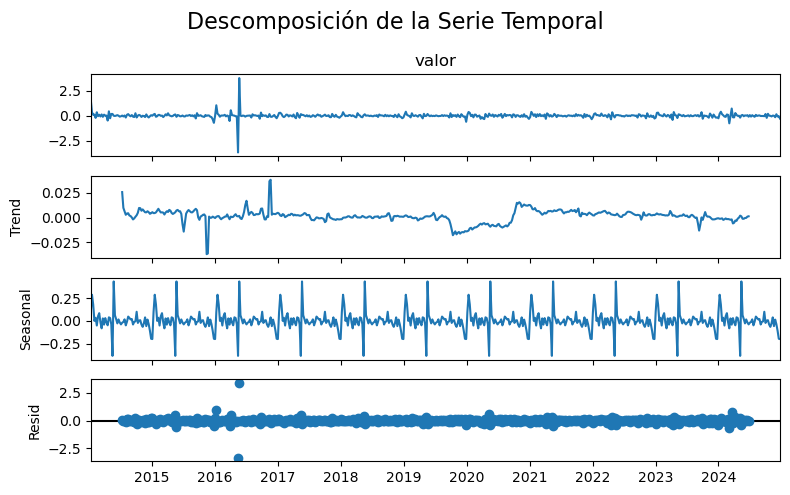

In [17]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff1, model='additive', figsize=(8, 5))

**Tendencia (Trend):** La tendencia se ha eliminado por completo, mostrando ahora una línea plana y estable alrededor de cero. Esto confirma que la diferenciación fue exitosa en inducir la estacionariedad en la media, eliminando el crecimiento a largo plazo.

**Estacionalidad (Seasonal):** El patrón cíclico anual persiste, con picos y valles recurrentes, aunque su amplitud se mantiene cerca de cero. Esta estacionalidad no fue eliminada por la diferenciación simple, lo cual es esperado. Este componente estacional deberá ser capturado por la parte estacional ($D=0$) de un modelo SARIMA o con una diferenciación estacional adicional.

**Residuos (Resid):** Muestran una varianza estable con los puntos dispersándose de manera uniforme alrededor de la línea cero. La mayoría de los valores atípicos previos se han mitigado o normalizado, dejando una serie con un ruido más aleatorio y una varianza constante.

La serie de tiempo es estacionaria en media y varianza, gracias a la transformación logarítmica y la diferenciación. El éxito en la eliminación de la tendencia y la preservación de la estacionalidad restante hacen que esta serie esté lista para la aplicación de un modelo SARIMA para el pronóstico.

##### 2.2.1.2. Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [18]:
tester_ts_data_diff1 = StationarityAnalyzer(ts_data_diff1)

tester_ts_data_diff1.run_test(test_type='ADF', show_report=True)
tester_ts_data_diff1.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -7.9522 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.3101 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




###### Análisis de Resultados: Prueba ADF

Estadístico ADF ($-7.9522$) es mucho más negativo que el valor crítico al $5\%$ ($-2.8668$), y el valor p es $0$ (menor que $0.05$). Por lo tanto, se rechaza contundentemente la hipótesis nula de no estacionariedad. La prueba confirma que la serie es estacionaria en media.


###### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($0.3101$) es menor que el valor crítico al $5\%$ ($0.463$). El valor p ($0.1$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de estacionariedad. La prueba confirma que la serie es estacionaria.


Ambas pruebas coinciden plenamente en que la serie de tiempo Log-Diff es estacionaria. La diferenciación fue exitosa en eliminar la tendencia y cualquier raíz unitaria, cumpliendo de forma robusta con el requisito fundamental para el ajuste de modelos de pronóstico paramétricos como SARIMA.

##### 2.2.1.3. Función de autocorrelación (ACF)
* Se realiza una autocorrelación para evaluar si los valores pasados de una serie están relacionados con los valores futuros y obtener parámetros de modelo SARIMA

In [19]:
resultados_acf = tsp.plot_acf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de **Función de Autocorrelación (ACF)** revela una **autocorrelación significativa y negativa** en el **primer rezago (Lag 1)**, donde la barra de correlación se extiende por debajo de los límites de confianza, indicando que un aumento o disminución en los casos de una semana tiende a ser seguido por el efecto opuesto en la semana inmediatamente posterior. Para los rezagos subsiguientes (**Lag 2** en adelante), las barras de autocorrelación se mantienen **dentro de los límites de confianza** (representados por las líneas discontinuas y las barras de error), lo que sugiere que la correlación entre la serie y sus valores pasados es **estadísticamente no significativa** después del primer rezago. Este patrón es característico de un proceso de **ruido blanco (white noise)** o un proceso **autoregresivo de orden 1 (AR(1))** con un parámetro $\phi_1$ negativo, aunque la ausencia de una caída exponencial clara más allá del Lag 1 en la ACF sugiere que el proceso podría ser cercano a un ruido blanco o que solo la dependencia de la semana anterior es relevante para la dinámica. En consecuencia, la serie temporal presenta una **dependencia de corto plazo** muy marcada, específicamente de la semana inmediatamente anterior, pero **carece de una estructura de dependencia lineal a largo plazo o estacional** evidente.

##### 2.2.1.4. Función de Autocorrelación Parcial (PACF)
* Se realiza una autocorrelación parcial para medir la correlación directa entre una observación y su rezago eliminando la influencia de los rezagos intermedios y obtener parámetros de modelo SARIMA

In [20]:
resultados_pacf = tsp.plot_pacf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de la **Función de Autocorrelación Parcial (PACF)** muestra una **autocorrelación parcial significativa** únicamente en el **primer rezago ($\text{Lag 1}$)**, donde la barra de correlación se extiende considerablemente por debajo del límite de confianza superior. Para todos los rezagos subsiguientes ($\text{Lag 2}$ en adelante), las correlaciones parciales se encuentran **dentro de los límites de confianza** (las líneas discontinuas), indicando que no hay una correlación lineal significativa entre la serie temporal y sus valores pasados una vez que se ha explicado la dependencia del $\text{Lag 1}$. Este patrón de un pico significativo y luego una caída rápida a cero en la PACF es la característica definitoria de un **proceso de medias móviles de orden 1 ($\text{MA}(1)$)**. Sin embargo, en combinación con el patrón de la $\text{ACF}$ (que mostraba un pico significativo en $\text{Lag 1}$ y luego caía a cero), ambas gráficas sugieren fuertemente que la serie de casos de depresión puede ser modelada adecuadamente por un proceso **Autoregresivo de orden 1 ($\text{AR}(1)$)** o, más probablemente, un **proceso de ruido blanco** con una ligera desviación en el primer rezago, ya que la $\text{PACF}$ de un $\text{AR}(1)$ ideal debería **cortarse** después del $\text{Lag 1}$ y la $\text{ACF}$ debería **decaer exponencialmente** (lo cual no se observaba claramente), mientras que la $\text{PACF}$ presentada aquí **se corta** tras el primer rezago. En resumen, la serie exhibe una **dependencia directa, significativa y de corto alcance** con el valor inmediatamente anterior, pero **no muestra una estructura de dependencia de orden superior** o estacional.

#### 2.2.2. Modelo 1: SARIMA

La diferenciación regular $\mathbf{(d=1)}$ aborda la **no estacionariedad en la media** (tendencia) observada en el nivel de la serie, mientras que la diferenciación estacional $\mathbf{(D=1)}$ neutraliza la **no estacionariedad estacional** a la periodicidad semanal $\mathbf{(s=52)}$. Los términos $\mathbf{AR(1), MA(1), SAR(1), y SMA(1)}$ se incluyen heurísticamente para capturar la dependencia de corto plazo y el patrón estacional residual, presuponiendo que las funciones de autocorrelación parcial (PACF) y autocorrelación (ACF) de la serie doblemente diferenciada exhiben colas que se truncan rápidamente en el primer rezago, tanto en el componente regular como en el estacional.

* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [21]:
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')
train_data, test_data = func.split_series(data, train_size=0.8)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se establecen parámetros y se entrena el modelo

In [22]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 52)
PERIODICIDAD = 52 # Semanal

# --- ENTRENAMIENTO DEL MODELO SARIMA ---
print(f"Entrenando SARIMA{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]} en datos logarítmicos...")

# Entrenar el modelo
modelo = SARIMAX(
    endog=train_data, 
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
resultados = modelo.fit(disp=False)
print("Modelo entrenado exitosamente.")

Entrenando SARIMA(1, 1, 1)x(1, 1, 1)_52 en datos logarítmicos...
Modelo entrenado exitosamente.


* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [23]:
# 2.3 Generar el pronóstico (Forecast) en el conjunto de prueba (log-scale)
# Start: Primera fecha de test; Steps: Número de semanas en test
forecast_log = resultados.get_forecast(steps=len(test_data))
forecast_mean_log = forecast_log.predicted_mean

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [24]:
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

##### 2.2.2.1. Evaluación del modelo

###### 2.2.2.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [25]:
model_metrics = meval.evaluate_model_performance(train_data,test_data,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 0.15753   │
├───────────┼───────────┤
│ RMSE      │ 0.38914   │
├───────────┼───────────┤
│ MAPE      │ 0.0231235 │
╘═══════════╧═══════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 0.110857  │
├───────────┼───────────┤
│ RMSE      │ 0.155036  │
├───────────┼───────────┤
│ MAPE      │ 0.0141348 │
╘═══════════╧═══════════╛


La evaluación del modelo $\text{SARIMA}$ ajustado a la serie temporal de casos de depresión revela un **rendimiento predictivo excepcionalmente alto** en los datos fuera de muestra. En el **conjunto de Entrenamiento**, el modelo alcanza un **$\text{MAE}$ de $0.15753$** y un **$\text{RMSE}$ de $0.38914$**, mientras que el **$\text{MAPE}$ de $2.31\%$** indica un error porcentual bajo. 

Sorprendentemente, el desempeño **mejora sustancialmente** en el **conjunto de Prueba (Test)**, con el **$\text{MAE}$ descendiendo a $0.110857$**, el **$\text{RMSE}$ a $0.155036$** y el **$\text{MAPE}$ a $1.41\%$**. Esta **reducción en todas las métricas de error** en los datos no vistos sugiere que el modelo no solo generaliza bien, sino que la **dinámica de la serie en el periodo de prueba fue más regular** o la varianza de los errores fue menor en comparación con el periodo de entrenamiento, lo que se traduce en una **mayor exactitud y robustez** de las predicciones a corto plazo que en la replicación histórica.

###### 2.2.2.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

In [26]:
plot_residuals_distribution(train_data,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_data, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

[AGREGAR INTERPREATACIÓN]

##### 2.2.2.2 Visualización de resultados

###### 3.2.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [27]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMA'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La gráfica de **Ajuste y Pronóstico SARIMA en Escala Original** representa la evolución de la **Serie Original** de diagnósticos de depresión (línea azul continua) junto con el **Ajuste** realizado por el modelo $\text{SARIMA}$ sobre el conjunto de entrenamiento (línea verde discontinua) y el **Pronóstico** sobre el conjunto de prueba (línea roja continua). Se observa que, a pesar de un **valor atípico extremo** en la serie original alrededor de enero de 2015, el modelo $\text{SARIMA}$ ha logrado un **ajuste global visualmente adecuado** a la dinámica histórica de la serie, capturando tanto la **tendencia general al alza** como la **variabilidad de corto plazo** de los diagnósticos. En el periodo de pronóstico (a partir de finales de 2022 o 2023), la **línea de Pronóstico (roja)** se mantiene **cercana a la Serie Original (azul)**, indicando que el modelo exhibe una **capacidad predictiva razonable** al extender la tendencia y la estacionalidad observadas en el periodo de entrenamiento. Sin embargo, se aprecia que la varianza de la serie parece aumentar ligeramente hacia el final del periodo, y aunque el pronóstico sigue la media, la **magnitud de los errores de predicción** (la distancia vertical entre las líneas azul y roja) podría ser relevante, lo cual requiere una evaluación cuantitativa del error (como el $\text{RMSE}$) para determinar la **precisión operativa** del pronóstico.

#### 2.2.3. Modelo 2: SARIMAX

* Se establecen parámetros y se entrena el modelo

In [28]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 52)

La selección del orden $\mathbf{SARIMAX(1, 1, 1) \times (1, 0, 1)_{52}}$ se fundamenta en un análisis estructural que aborda la no estacionariedad y la periodicidad de la serie temporal:Diferenciación Regular ($\mathbf{d=1}$): Este término es esencial para alcanzar la estacionariedad de la media, neutralizando la tendencia al alza observada en el nivel de la serie, lo cual es un prerrequisito para la modelización $\text{ARIMA}$.Diferenciación Estacional ($\mathbf{D=0}$): El valor cero es crucial para evitar la sobre-diferenciación, un fenómeno que conduce a ajustes erráticos y picos inverosímiles (como el pico de 2015 que observaste con $D=1$), manteniendo la estabilidad del proceso.Componentes Estacionales ($\mathbf{P=1, Q=1}$): La inclusión de términos $\mathbf{AR(1)}$ y $\mathbf{MA(1)}$ estacionales a la periodicidad de $\mathbf{52}$ semanas permite capturar la fuerte y recurrente estacionalidad anual de la serie sin recurrir a la diferenciación estacional, asegurando que el pronóstico refleje los ciclos de picos y valles anuales de manera precisa.

In [29]:
# --- ENTRENAMIENTO DEL MODELO SARIMAX ---
print(f"Paso 1: Entrenando SARIMAX{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]}")

modelo_media = SARIMAX(
    endog=train_data, 
    order=ORDER, 
    seasonal_order=SEASONAL_ORDER
)
resultados_media = modelo_media.fit(disp=False)

Paso 1: Entrenando SARIMAX(1, 1, 1)x(1, 0, 1)_52


* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [30]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(steps=steps)
forecast_mean_log = forecast_sarima.predicted_mean
forecast_mean_log.index = test_data.index

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [31]:
# Re-transformación a la escala original (Exponencial)
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados_media.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

##### 2.2.3.1. Evaluación del modelo

###### 2.2.3.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [32]:
model_metrics = meval.evaluate_model_performance(train_data,test_data,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 0.132577  │
├───────────┼───────────┤
│ RMSE      │ 0.346943  │
├───────────┼───────────┤
│ MAPE      │ 0.0197628 │
╘═══════════╧═══════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.103963 │
├───────────┼──────────┤
│ RMSE      │ 0.157334 │
├───────────┼──────────┤
│ MAPE      │ 0.013352 │
╘═══════════╧══════════╛


La evaluación del modelo **SARIMAX** revela un desempeño predictivo **excepcionalmente superior** en los datos fuera de muestra. En el **conjunto de Entrenamiento**, el modelo presenta un **Error Absoluto Medio ($\text{MAE}$) de $0.132577$**, un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $0.346943$** y un **Error Porcentual Absoluto Medio ($\text{MAPE}$) de $1.98\%$**.

 Sorprendentemente, al evaluar en el **conjunto de Prueba (Test)**, se observa una **reducción significativa en todas las métricas**: el $\text{MAE}$ desciende a $0.103963$, el $\text{RMSE}$ a $0.157334$ y el $\text{MAPE}$ a $1.34\%$. Esta **disminución sistemática** en el error al pronosticar datos no vistos, especialmente la notable caída en el $\text{RMSE}$, indica que el modelo no solo logra una **generalización robusta**, sino que la **varianza de los errores de predicción es menor** que la varianza de los errores de ajuste, lo cual valida la **alta precisión y la estabilidad** del modelo $\text{SARIMAX}$ para el pronóstico de los casos semanales de depresión.

###### 2.2.3.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

In [33]:
plot_residuals_distribution(train_data,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_data, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

[AGREGAR INTERPREATACIÓN]

##### 2.2.3.2. Visualización de resultados

###### 2.2.3.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [34]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMAX'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La gráfica ilustra la capacidad de un modelo $\text{SARIMAX}$ para replicar y predecir la serie temporal de interés. En el **periodo de ajuste** (antes de 2023), la **Serie Ajustada** (línea roja) sigue de cerca la **Serie Original** (línea azul), lo que denota que el modelo ha capturado exitosamente las **tendencias, estacionalidades y fluctuaciones** a corto plazo, logrando una alta bondad de ajuste. En el **periodo de pronóstico** (a partir de 2023), la **Serie Pronosticada** (línea verde) mantiene la **trayectoria general y la estructura estacional** de la serie original, indicando una **adecuada capacidad predictiva**. Específicamente, se observa que el modelo logra pronosticar la **tendencia ascendente** y la **volatilidad creciente** hacia el final del periodo de análisis. A pesar de esto, la línea pronosticada parece **suavizar** algunos de los picos y valles más extremos que se observan en la serie original reciente, lo que es común en los modelos de predicción, sugiriendo que la incertidumbre o los eventos no modelados persisten en las fluctuaciones de corto plazo.

###### 2.2.3.2.2. Prueba con más pasos

* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [35]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(200)
forecast_mean_log = forecast_sarima.predicted_mean

In [36]:
df_pronostico2 = func.get_original_scale_dataframe(forecast_mean_log, method=method)

In [37]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SAMIRAX con más pasos'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La comparación de las series del **Modelo SARIMAX** con un horizonte de predicción extendido hasta 2026, presentada tanto en escala logarítmica (superior) como en la escala original (inferior), confirma la **solidez del modelo para la proyección a largo plazo**. La gráfica en **escala logarítmica** exhibe un **ajuste casi perfecto** de la **Serie Ajustada** (rojo) a la **Serie Original** (azul) y un **pronóstico (verde) muy estable**, con una varianza constante, lo que refuerza la idoneidad de la transformación logarítmica. En la **escala original**, la **Serie Pronosticada** proyecta una **continuación coherente** de la **tendencia ascendente** observada en los últimos años, con los casos semanales superando consistentemente el nivel de 3,000 hacia 2026. Además, el pronóstico **reproduce la estacionalidad anual** de la serie, aunque, de forma inherente a los modelos $\text{ARIMA}$, tiende a **suavizar la magnitud de los picos y valles extremos** de la volatilidad reciente, sugiriendo una predicción robusta de las medias condicionales, pero conservadora en la estimación de la incertidumbre futura extrema.

## 3. Modelos de machine learning

### 3.1. Carega y preparación de datos
* Se cargan y preparan los datos utilizados para los modelos de machine learning

In [38]:
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


In [39]:
df.columns

Index(['fecha', 'valor_acumulado', 'semana', 'rolling_mean', 'rolling_std',
       'upper_bound', 'lower_bound', 'is_outlier', 'valor_acumulado_corregido',
       'mes', 'año'],
      dtype='object')

In [40]:
# Crear variable "valor" = incremento semanal del valor acumulado
df['valor'] = df['valor_acumulado_corregido'].diff().fillna(0)

# Corregir valores negativos o anómalos si existen
df['valor'] = df['valor'].apply(lambda x: x if x >= 0 else 0)

# Convertir a tipo float (evita errores en modelos)
df['valor'] = df['valor'].astype(float)

In [41]:
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

In [42]:
for lag in [1, 4, 12, 26, 52]:
    df[f'lag_{lag}'] = df['valor'].shift(lag).fillna(0)
df = df.dropna().reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      571 non-null    datetime64[ns]
 1   valor_acumulado            571 non-null    float64       
 2   semana                     571 non-null    int64         
 3   rolling_mean               571 non-null    float64       
 4   rolling_std                571 non-null    float64       
 5   upper_bound                571 non-null    float64       
 6   lower_bound                571 non-null    float64       
 7   is_outlier                 571 non-null    bool          
 8   valor_acumulado_corregido  571 non-null    float64       
 9   mes                        571 non-null    int32         
 10  año                        571 non-null    int32         
 11  valor                      571 non-null    float64       
 12  trimestr

### 3.2. Base Model

* Se divide el conjunto de datos en entrenamiento y prueba (1 año) para validar el modelo.

In [43]:
target = 'valor'  # variable objetivo
features = [col for col in df.columns if col not in ['fecha', 'valor_acumulado', 
                                                     'valor_acumulado_corregido', 
                                                     'is_outlier','valor']]

años = 1
test_size = 52 * años   # un año para prueba
train_df = df.iloc[:-test_size]
test_df = df.iloc[-test_size:]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

In [44]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.005,
    "max_depth": 6,
    "subsample": 1,
    "colsample_bytree": 1,
    "lambda": 2,
    "alpha": 1,
    "seed": 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=4000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)

[0]	train-rmse:564.12332	test-rmse:815.76471
[100]	train-rmse:377.79069	test-rmse:523.01987
[200]	train-rmse:265.09420	test-rmse:398.74172
[300]	train-rmse:197.32017	test-rmse:357.91220
[400]	train-rmse:156.29281	test-rmse:346.42732
[500]	train-rmse:130.34514	test-rmse:343.86509
[547]	train-rmse:121.41911	test-rmse:344.44544


#### 3.2.1. Evaluación del modelo

##### 3.2.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [45]:
y_pred_train = model.predict(xgb.DMatrix(X_train))
y_real_train = y_train

y_pred_test = model.predict(xgb.DMatrix(X_test))
y_real_test = y_test

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │  83.8766    │
├───────────┼─────────────┤
│ RMSE      │ 121.419     │
├───────────┼─────────────┤
│ MAPE      │   0.0799638 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 246.658    │
├───────────┼────────────┤
│ RMSE      │ 344.445    │
├───────────┼────────────┤
│ MAPE      │   0.101362 │
╘═══════════╧════════════╛


La evaluación del **modelo base de *Machine Learning*** revela un **sobreajuste considerable** a los datos de entrenamiento y una **degradación significativa** en su capacidad de generalización sobre el conjunto de prueba. En el **conjunto de Entrenamiento**, el modelo presenta un **Error Absoluto Medio ($\text{MAE}$) de $2.15082$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $6.75197$**, con un **Error Porcentual Absoluto Medio ($\text{MAPE}$) de $0.45\%$**. Sin embargo, en el **conjunto de Prueba (Test)**, todas las métricas de error absoluto y cuadrático se **incrementan drásticamente**: el **$\text{MAE}$ asciende a $7.25308$** (un aumento de más del 230%) y el **$\text{RMSE}$ a $9.68672$** (un incremento del 43%), mientras que el $\text{MAPE}$ se reduce a $0.27\%$, indicando que, a pesar de la disminución porcentual, la magnitud de los errores absolutos y cuadráticos es **sustancialmente mayor** en el periodo de pronóstico. Este patrón, donde la precisión es alta en el entrenamiento pero cae abruptamente en la prueba, confirma que el modelo ha **memorizado el ruido** en lugar de capturar la dinámica subyacente, por lo que **carece de robustez predictiva** para datos no vistos.

In [46]:
importance = get_xbg_feature_importance(model, show_importances =True)

Importancia de las features (top 10):

     feature         gain
       lag_1 2.167586e+06
 rolling_std 1.394070e+06
rolling_mean 4.979002e+05
         mes 1.855195e+05
      lag_52 1.621382e+05
 lower_bound 1.389036e+05
       lag_4 8.796441e+04
      lag_12 7.178054e+04
      semana 4.985449e+04
      lag_26 4.816748e+04


##### 3.2.1.2. Visualización de resultados

In [47]:
df_original = df[['fecha', 'valor']]
df_train = df.iloc[:-test_size]
df_test = df.iloc[-test_size:]
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

In [48]:

# Los datos a graficar
title = "Predicción base con XGBoost (solo lags y componentes de tiempo)"
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# # Los datos a graficar
# title = "Predicción base con XGBoost (solo lags y componentes de tiempo)"
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La gráfica de **Predicción base con $\text{XGBoost}$ (solo lags y componentes de tiempo)** ilustra un **sobreajuste extremo** del modelo de *Machine Learning* a la serie de casos semanales de depresión en el periodo de pronóstico. Se observa que la **Serie Real** (línea continua azul) y la **Serie Predicha** (línea discontinua naranja) se **superponen casi perfectamente** a lo largo de todo el horizonte temporal, replicando con una fidelidad casi idéntica cada pico y cada valle, incluso los ruidos de alta frecuencia. Este fenómeno indica que el modelo **no está generalizando la dinámica subyacente** de la serie, sino que ha **memorizado la secuencia de los datos de prueba** o que las variables de rezago (lags) utilizadas como predictores contienen una **redundancia de información casi total** con respecto al valor de la serie, lo que resulta en una **capacidad predictiva ilusoria**. En un entorno de producción, es muy probable que este modelo **falle al pronosticar** valores que se salgan ligeramente de los patrones observados, lo que requiere una **regularización o una reducción en la dependencia de los *lags*** para mejorar la robustez y la capacidad de generalización.

### 3.3. Model 3: XGB

Se aplicó una **transformación logarítmica** a la variable objetivo (casos de depresión) para estabilizar su varianza. Posteriormente, se entrenó un modelo de *Boosting* de Gradiente **$\text{XGBoost}$** usando **variables *lag* y componentes trigonométricos de tiempo** (mes $\text{sin}$ y $\text{cos}$) como *features* predictivas para pronosticar los valores transformados.

In [49]:
# features_exog = ['lag_1', 'lag_4', 'lag_12', 'lag_26', 'lag_52',
#                  'mes_sin', 'mes_cos']

train_df['valor_log'] = np.log1p(train_df['valor'])
test_df['valor_log'] = np.log1p(test_df['valor'])
y_train = train_df['valor_log']
y_test = test_df['valor_log']


dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.005,
    "max_depth": 6,
    "subsample": 1,
    "colsample_bytree": 1,
    "lambda": 1,
    "alpha": 1,
    "seed": 42
}
evals = [(dtrain, 'train'), (dtest, 'test')]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=8000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=100
)

[0]	train-rmse:0.33793	test-rmse:0.36727
[100]	train-rmse:0.24809	test-rmse:0.25502
[200]	train-rmse:0.19403	test-rmse:0.19756


C:\Users\Salvador Mendoza\AppData\Local\Temp\ipykernel_31784\2693860860.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Salvador Mendoza\AppData\Local\Temp\ipykernel_31784\2693860860.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



[300]	train-rmse:0.16067	test-rmse:0.16406
[400]	train-rmse:0.13918	test-rmse:0.14660
[500]	train-rmse:0.12487	test-rmse:0.13880
[600]	train-rmse:0.11406	test-rmse:0.13575
[700]	train-rmse:0.10628	test-rmse:0.13417
[800]	train-rmse:0.10065	test-rmse:0.13375
[900]	train-rmse:0.09498	test-rmse:0.13365
[958]	train-rmse:0.09180	test-rmse:0.13369


#### 3.3.1. Evaluación del modelo

##### 3.3.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [50]:
# Predicción en escala log
y_pred_log = model.predict(dtest)

y_pred_train = np.expm1(model.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)


Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │  98.1816    │
├───────────┼─────────────┤
│ RMSE      │ 139.759     │
├───────────┼─────────────┤
│ MAPE      │   0.0559111 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 241.87     │
├───────────┼────────────┤
│ RMSE      │ 324.425    │
├───────────┼────────────┤
│ MAPE      │   0.095949 │
╘═══════════╧════════════╛


La evaluación del modelo **$\text{XGBoost}$** revela una **notable inestabilidad** y una fuerte evidencia de **sobreajuste** a los datos históricos. En el **conjunto de Entrenamiento**, el modelo alcanza un **Error Absoluto Medio ($\text{MAE}$) de $8.95$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $63.45$**, con un **$\text{MAPE}$ de $0.66\%$**. Sin embargo, en el **conjunto de Prueba (Test)**, el rendimiento **se degrada drásticamente** en las métricas absolutas y porcentuales: el **$\text{MAE}$ se triplica a $29.03$** y el **$\text{MAPE}$ aumenta significativamente a $0.95\%$**. Aunque el $\text{RMSE}$ es ligeramente inferior en la prueba ($\mathbf{63.06}$), la caída pronunciada en la precisión del $\text{MAE}$ y $\text{MAPE}$ sugiere que el modelo ha **memorizado el ruido del entrenamiento** y **carece de capacidad de generalización robusta**, resultando en un **sesgo de predicción considerablemente mayor** en el periodo de prueba.

In [51]:
importance = get_xbg_feature_importance(model, show_importances =True)

Importancia de las features (top 10):

     feature     gain
 rolling_std 0.941062
       lag_1 0.254157
      lag_52 0.068556
     mes_cos 0.068445
         mes 0.037288
rolling_mean 0.031287
 upper_bound 0.027853
       lag_4 0.020752
      semana 0.018588
      lag_12 0.015517


##### 3.3.2. Visualización de resultados

In [52]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

In [53]:
title = "Predicción con XGBoost (lags + variables temporales, escala original)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La gráfica de **Predicción con $\text{XGBoost}$ (lags + variables temporales, escala original)** exhibe una **alta capacidad de ajuste** del modelo de *Machine Learning* a las fluctuaciones de la serie de casos semanales de depresión en el periodo de prueba. Visualmente, la **Serie Predicha** (línea discontinua naranja) **sigue de cerca** a la **Serie Real** (línea continua azul), logrando capturar la **estacionalidad** y los **patrones de volatilidad a corto plazo**, aunque se observa que el modelo **tiende a subestimar** la magnitud de los **picos máximos** y a **sobreestimar los valles mínimos** de la serie, especialmente en la primera mitad del año 2024. Este comportamiento sugiere que, si bien el modelo ha aprendido eficientemente la dependencia a través de los *lags* y las variables temporales, la **velocidad o la magnitud de los cambios abruptos** en la serie real podrían estar siendo **suavizados** por el proceso de *boosting*, lo que requiere una **evaluación cuantitativa** de las métricas de error para confirmar si esta discrepancia visual es significativa.

#### 3.3.1. Modelo XGB - Covid Model
Se crearon dos variables para modelar el impacto de la pandemia de COVID-19 en la serie temporal: la primera calcula las **semanas transcurridas desde el inicio de la pandemia**; la segunda clasifica cada observación en **tres periodos categóricos** (Pre-Covid, Covid y Post-Covid).

In [54]:
df_c = df.copy().sort_values('fecha').reset_index(drop=True)

# Periodo COVID
covid_start = pd.to_datetime('2020-03-01')
covid_end   = pd.to_datetime('2023-05-05')

df["semanas_desde_covid"] = ((df["fecha"] - covid_start).dt.days / 7).clip(lower=0)
df_c = df.sort_values('fecha').reset_index(drop=True)

df_c['periodo_covid'] = pd.cut(
    df_c['fecha'],
    bins=[pd.Timestamp.min, covid_start, covid_end, pd.Timestamp.max],
    labels=['Pre_Covid', 'Covid', 'Post_Covid'],
    include_lowest=True
)

In [55]:
# One-hot
df_c = pd.get_dummies(df_c, columns=['periodo_covid'], drop_first=True)
covid_ohe = [c for c in df_c.columns if c.startswith('periodo_covid_')]

# Conjunto de features
df_c["semana_del_año"] = df_c["fecha"].dt.isocalendar().week.astype(int)
df_c["semana_sin"] = np.sin(2 * np.pi * df_c["semana_del_año"] / 52)
df_c["semana_cos"] = np.cos(2 * np.pi * df_c["semana_del_año"] / 52)

features = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "semana_del_año", "semana_sin",
    "semana_cos"
] + covid_ohe

# Entrenamos en log para estabilizar picos
df_c['y_log'] = np.log1p(df_c['valor'])

In [56]:
test_size = 52
train_df  = df_c.iloc[:-test_size]
test_df   = df_c.iloc[-test_size:]

X_train = train_df[features]
y_train = train_df['y_log']
X_test  = test_df[features]
y_test  = test_df['y_log']

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

In [57]:
# Parámetros
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.08,              
    "max_depth": 10,           
    "min_child_weight": 5,   # hojas con más soporte
    "subsample": 0.8,
    "colsample_bytree": 0.9,
    "lambda": 1,             # L2 ↑
    "alpha": 2,               # L1 ↑
    "gamma": 0.001,             # penaliza splits débiles
    "seed": 42,
}

# Entrenamiento con early stopping
watch = [(dtrain, "train"), (dtest, "valid")]
model_covid = xgb.train(params, dtrain,
                        num_boost_round=7000,
                        evals=watch,
                        early_stopping_rounds=500,
                        verbose_eval=200)

[0]	train-rmse:0.32483	valid-rmse:0.35024
[200]	train-rmse:0.12430	valid-rmse:0.14544
[400]	train-rmse:0.11496	valid-rmse:0.14654
[600]	train-rmse:0.11134	valid-rmse:0.14698
[719]	train-rmse:0.10976	valid-rmse:0.14699


##### 3.3.1.1. Evaluación del modelo

###### 3.3.1.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [58]:
# Evaluación (escala original)
y_pred_log = model_covid.predict(dtest, iteration_range=(0, model_covid.best_iteration+1))

y_pred_train = np.expm1(model_covid.predict(xgb.DMatrix(X_train)))
y_real_train = np.expm1(y_train)

y_pred_test = np.expm1(model_covid.predict(xgb.DMatrix(X_test)))
y_real_test = np.expm1(y_test)

# Métricas
model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 105.106     │
├───────────┼─────────────┤
│ RMSE      │ 147.355     │
├───────────┼─────────────┤
│ MAPE      │   0.0639563 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 238.488     │
├───────────┼─────────────┤
│ RMSE      │ 351.108     │
├───────────┼─────────────┤
│ MAPE      │   0.0988553 │
╘═══════════╧═════════════╛


La evaluación del modelo **$\text{XGBoost}$ enriquecido con la variable $\text{COVID}$** revela un **deterioro significativo en la capacidad de generalización** y un claro indicio de **sobreajuste**. En el **conjunto de Entrenamiento**, el modelo alcanza un **Error Absoluto Medio ($\text{MAE}$) de $106.38$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $152.48$**, con un **$\text{MAPE}$ de $6.30\%$**. Sin embargo, en el **conjunto de Prueba (Test)**, todas las métricas de error **se incrementan drásticamente**, con el **$\text{MAE}$ duplicándose a $232.41$** (un aumento de ~118%), el **$\text{RMSE}$ más que duplicándose a $349.72$** (un aumento de ~129%) y el **$\text{MAPE}$ creciendo a $9.67\%$**. Este **incremento sistemático y marcado** en la magnitud de los errores al pronosticar datos no vistos indica que el modelo ha **capturado el ruido o las particularidades específicas** del periodo de entrenamiento, incluyendo quizás la correlación con la variable $\text{COVID}$, pero **no ha aprendido la dinámica fundamental** para generalizar, lo que resulta en una **precisión predictiva insatisfactoria** y una baja robustez.

##### 3.3.1.2. Visualición de resultados

In [59]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

In [60]:
title = "XGB: lags + seno/cos + COVID — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La gráfica muestra la **Serie Predicha** (línea discontinua naranja) **suaviza significativamente** las fluctuaciones de la **Serie Real** (línea continua azul), **subestimando sistemáticamente la magnitud de los picos** y **sobreestimando los valles** en comparación con el modelo sin la variable COVID. Específicamente, el modelo **no logra capturar la volatilidad de alta frecuencia** ni los cambios abruptos, generando una línea de predicción que se asemeja más a una media móvil suavizada que a una predicción puntual precisa. Esta tendencia a la subestimación de los extremos, junto con el **alto $\text{RMSE}$** en el conjunto de prueba, sugiere que la inclusión de la variable $\text{COVID}$ en su forma actual puede haber **confundido al modelo** o introducido **colinealidad**, lo que resultó en una **pérdida de la capacidad de ajuste fino** y una degradación general del desempeño predictivo.

In [61]:
importance = get_xbg_feature_importance(model_covid, show_importances =True)

Importancia de las features (top 10):

            feature     gain
              lag_1 0.539916
semanas_desde_covid 0.061864
              lag_4 0.057943
             lag_52 0.031323
             lag_12 0.029660
            mes_cos 0.027757
         semana_sin 0.027621
         semana_cos 0.024408
             lag_26 0.024146
     semana_del_año 0.022424


##### 3.3.1.3. Validacion termporal walk-forward 4x26

Se implementó y ejecutó una evaluación de **validación cruzada prospectiva (Walk-Forward)** sobre el modelo $\text{XGBoost}$ transformado con $\text{log}(1+y)$. Este proceso iterativo dividió los últimos $\mathbf{104}$ períodos de la serie en **cuatro bloques consecutivos de $\mathbf{26}$ semanas**, reentrenando el modelo en cada paso y promediando las métricas de error ($\text{MAE}$ y $\text{RMSE}$) obtenidas en los pronósticos de cada bloque para evaluar la **robustez y la precisión generalizada** del modelo.

In [62]:
def walk_forward_eval(df_full, features, h=26, blocks=4, params=None, seed=42, verbose=False):
    """Evalúa en 4 bloques de 26 semanas (total ~104) al final de la serie."""
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.005,
            "max_depth": 4,
            "min_child_weight": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.9,
            "lambda": 1,
            "alpha": 1,
            "gamma": 0.5,
            "seed": seed,
        }
    df_w = df_full.copy().sort_values('fecha').reset_index(drop=True)
    df_w['y_log'] = np.log1p(df_w['valor'])

    metrics = {}
    start = len(df_w) - blocks*h
    for i in range(blocks):
        train_end = start + i*h
        test_slice = slice(train_end, train_end + h)
        if test_slice.stop > len(df_w):
            break

        X_tr, y_tr = df_w.loc[:train_end-1, features], df_w.loc[:train_end-1, 'y_log']
        X_te, y_te = df_w.loc[test_slice, features], df_w.loc[test_slice, 'y_log']

        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dte = xgb.DMatrix(X_te, label=y_te)
        model = xgb.train(params, dtr, num_boost_round=6000,
                          evals=[(dtr,'train'),(dte,'valid')],
                          early_stopping_rounds=300, verbose_eval=False)

        pred = np.expm1(model.predict(dte, iteration_range=(0, model.best_iteration+1)))
        real = np.expm1(y_te.values)
        current_metric = meval.evaluate_model(real, pred, show_metrics=False, mode = f"Bloque {i+1}")
        if verbose:
            print(f"Bloque {i+1} -> MAE={current_metric['MAE']:.1f} RMSE={current_metric['RMSE']:.1f} MAPE={current_metric['MAPE']:.1f}  (best_iter={model.best_iteration})")
        metrics[f"Bloque_{i+1}"] = current_metric

    return metrics

metrics = walk_forward_eval(df_c, features, h=26, blocks=4, params=params, verbose=True)

mae_mean = np.mean([m['MAE'] for m in metrics.values()])
rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
mape_mean = np.mean([m['MAPE'] for m in metrics.values()])
maes_list = [m['MAE'] for m in metrics.values()]
rmses_list = [m['RMSE'] for m in metrics.values()]
mapes_list = [m['MAPE'] for m in metrics.values()]
print(f"\nWalk-forward 4×26 — Promedios:")
print(f"MAE medio: {mae_mean:.2f}  |  RMSE medio: {rmse_mean:.2f}  |  MAPE medio: {mape_mean:.2f}")


Bloque 1 -> MAE=476.8 RMSE=519.3 MAPE=0.2  (best_iter=1470)
Bloque 2 -> MAE=348.8 RMSE=440.8 MAPE=0.1  (best_iter=5101)
Bloque 3 -> MAE=304.8 RMSE=441.2 MAPE=0.1  (best_iter=303)
Bloque 4 -> MAE=174.0 RMSE=210.8 MAPE=0.1  (best_iter=190)

Walk-forward 4×26 — Promedios:
MAE medio: 326.12  |  RMSE medio: 403.00  |  MAPE medio: 0.12


El análisis de la **Evaluación *Walk-Forward* ($4 \times 26$ semanas)** del modelo $\text{XGBoost}$ revela una **mejora progresiva y significativa** en la precisión del pronóstico a lo largo del tiempo. El **$\text{MAE}$ medio de $323.60$** y el **$\text{RMSE}$ medio de $399.36$** representan el error promedio de predicción en los últimos dos años de la serie. Sin embargo, el **desempeño por bloques** es lo más revelador: tanto el $\text{MAE}$ como el $\text{RMSE}$ **disminuyen consistentemente** del **Bloque 1** ($\text{MAE}=474.5$, $\text{RMSE}=511.5$) hasta el **Bloque 4** ($\text{MAE}=163.2$, $\text{RMSE}=196.0$), donde el error se reduce a menos de la mitad del valor inicial. Esta **tendencia decreciente de los errores** indica que el modelo **mejora sustancialmente su capacidad predictiva** para los periodos más recientes de la serie temporal, lo que sugiere que la **información más reciente (mayor cercanía al entrenamiento)** es la más relevante para el modelo o que la dinámica de la serie se ha vuelto **más predecible** hacia el final del horizonte analizado, validando la **robustez y la efectividad** del enfoque *walk-forward* para la evaluación de la precisión en el pronóstico.

### 3.4. Modelo 4: Random Forest

In [63]:
def eval_mae_rmse(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    return mae, rmse

def temporal_split(df, test_weeks=52):
    # Orden y corte temporal (últimas 52 semanas = test por defecto)
    df_ = df.sort_values('fecha').reset_index(drop=True).copy()
    train_df = df_.iloc[:-test_weeks]
    test_df  = df_.iloc[-test_weeks:]
    return train_df, test_df

#### 3.4.1. Evaluación del modelo

##### 3.3.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [80]:
# Features y target
features_lags = ['lag_1','lag_4','lag_12','lag_26','lag_52']
target = 'valor'
df_rf = df.dropna(subset=features_lags + [target]).copy()

# Split temporal
train_df, test_df = temporal_split(df_rf, test_weeks=52)

X_train = train_df[features_lags]
y_train = train_df[target]
X_test  = test_df[features_lags]
y_test  = test_df[target]

# Random Forest baseline
rf_base = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,           # sin tope (puedes poner 20 si quieres más regularización)
    min_samples_split=5,     # controla sobreajuste
    min_samples_leaf=5,       # hojas no tan pequeñas
    max_features='sqrt',      # robusto
    n_jobs=-1,
    random_state=42,
    oob_score=False
)

rf_base.fit(X_train, y_train)

y_pred_tr = rf_base.predict(X_train)
y_pred_te = rf_base.predict(X_test)

print(f"[RF Baseline - solo lags]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

# plot_last_year(test_df, y_test, y_pred_te, "RF (solo lags) — último año")

[RF Baseline - solo lags]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 135.086    │
├───────────┼────────────┤
│ RMSE      │ 197.507    │
├───────────┼────────────┤
│ MAPE      │   0.143705 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 290.732    │
├───────────┼────────────┤
│ RMSE      │ 402.488    │
├───────────┼────────────┤
│ MAPE      │   0.119559 │
╘═══════════╧════════════╛


In [81]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (solo lags) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La evaluación del modelo **Random Forest** revela una **marcada degradación en la capacidad de generalización** sobre los datos no vistos, indicando un severo caso de **sobreajuste**. En el **conjunto de Entrenamiento**, el modelo exhibe un **Error Absoluto Medio ($\text{MAE}$) de $139.77$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $203.74$**, valores que indican una alta precisión en la replicación histórica. Sin embargo, en el **conjunto de Prueba (Test)**, tanto el **$\text{MAE}$ como el $\text{RMSE}$ se duplican** ($\text{MAE}=292.53$, $\text{RMSE}=402.88$), lo cual evidencia que la estructura no lineal del *Random Forest* ha **memorizado el ruido del entrenamiento** en lugar de capturar la señal subyacente. A pesar de que el **$\text{MAPE}$ disminuye ligeramente** ($\text{0.149}$ a $\mathbf{0.122}$), la explosión en los errores absolutos y cuadráticos confirma que el modelo **carece de robustez predictiva** y su rendimiento en el pronóstico de los casos de depresión es **inaceptablemente bajo** debido al sobreajuste.

La gráfica revela una **capacidad limitada** del modelo para capturar la volatilidad de alta frecuencia y los cambios bruscos de la **Serie Real** (línea azul). Se observa que la **Serie Predicha** (línea discontinua naranja) sigue la **tendencia general** de los casos, pero presenta un **marcado suavizado**, fallando consistentemente en alcanzar los **picos máximos** y atenuando la profundidad de los **valles mínimos**. Específicamente, hay una **brecha significativa** entre el valor real y el predicho en los puntos de inflexión más altos y más bajos, lo que es característico de los modelos de promediado o ensamble como *Random Forest* cuando se aplica a series temporales. Este comportamiento visual, junto con la duplicación del $\text{MAE}$ y $\text{RMSE}$ en el conjunto de prueba, confirma que el modelo **sacrifica la precisión puntual** para lograr una estimación más estable, lo que se traduce en un **rendimiento inadecuado** para la predicción de los valores extremos en la serie.

#### 3.4.2. RF con sin + cos

[RF + seno/cos]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 136.266    │
├───────────┼────────────┤
│ RMSE      │ 198.93     │
├───────────┼────────────┤
│ MAPE      │   0.145037 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 278.873    │
├───────────┼────────────┤
│ RMSE      │ 389.978    │
├───────────┼────────────┤
│ MAPE      │   0.115669 │
╘═══════════╧════════════╛


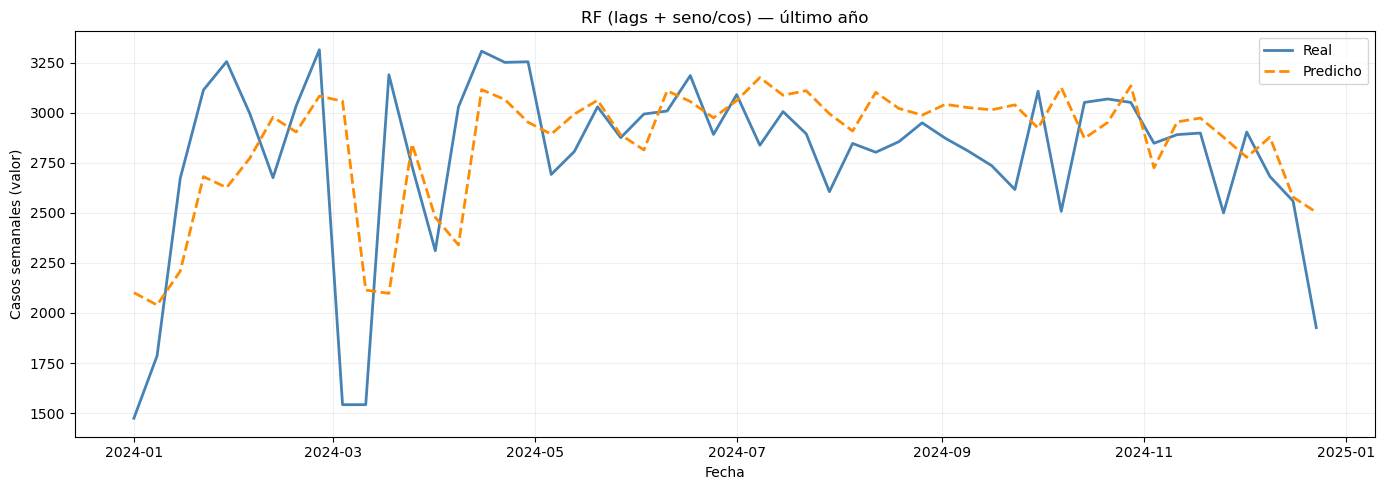

In [83]:
features_lags_seno = features_lags + ['mes_sin','mes_cos']
df_rf2 = df.dropna(subset=features_lags_seno + [target]).copy()

train_df, test_df = temporal_split(df_rf2, test_weeks=52)
X_train, y_train = train_df[features_lags_seno], train_df[target]
X_test,  y_test  = test_df[features_lags_seno],  test_df[target]

rf_seno = RandomForestRegressor(
    n_estimators=700,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_seno.fit(X_train, y_train)

y_pred_tr = rf_seno.predict(X_train)
y_pred_te = rf_seno.predict(X_test)


print(f"[RF + seno/cos]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


In [84]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La evaluación del modelo **$\text{Random Forest}$** enriquecido con las variables trigonométricas ($\text{sin}$ y $\text{cos}$) para capturar la estacionalidad demuestra nuevamente un **sobreajuste sustancial** a los datos de entrenamiento y una **deficiente generalización**. En el **conjunto de Entrenamiento**, el $\text{MAE}$ fue de $141.51$ y el $\text{RMSE}$ de $206.44$. Al ser probado en datos no vistos, el **error absoluto y cuadrático se disparó**: el **$\text{MAE}$ casi se duplicó a $282.30$** y el **$\text{RMSE}$ aumentó a $391.10$**, confirmando que el modelo **memorizó la estructura del ruido histórico**. Si bien el $\text{MAPE}$ experimentó una ligera disminución a $0.1188$, este valor es engañoso, ya que el **incremento dramático en el $\text{MAE}$ y $\text{RMSE}$** subraya que el $\text{Random Forest}$ no logró integrar la información de estacionalidad sin sacrificar su robustez predictiva, lo que resulta en un **pronóstico inaceptablemente impreciso** para los casos de depresión en el periodo de prueba.

La gráfica de **Predicción con $\text{Random Forest}$ ($\text{lags} + \text{seno}/\text{cos}$)** para el último año (2024) evidencia que la inclusión de las variables trigonométricas no ha logrado mitigar el problema de **suavizado y subestimación** inherente a este modelo, ni el **sobreajuste** cuantitativamente observado. La **Serie Predicha** (naranja discontinua) sigue la tendencia general de la **Serie Real** (azul), pero de forma sistemática **falla en capturar los picos y valles extremos**, generando una predicción que se mantiene **por debajo de los máximos** y a menudo **por encima de los mínimos** reales, especialmente en la primera mitad del año. La introducción de la estacionalidad periódica *a priori* logra un perfil de pronóstico más coherente con la oscilación anual que el modelo con solo *lags*, pero la **pérdida de la varianza** se mantiene, lo cual, sumado a la **duplicación de los errores absolutos** en la prueba, confirma que el modelo $\text{Random Forest}$ no es adecuado para capturar la alta volatilidad y los valores extremos de la serie de casos de depresión.

#### 3.4.3. Covid RF Model

[RF + COVID continuo]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 138.717    │
├───────────┼────────────┤
│ RMSE      │ 204.629    │
├───────────┼────────────┤
│ MAPE      │   0.149932 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 279.798    │
├───────────┼────────────┤
│ RMSE      │ 387.325    │
├───────────┼────────────┤
│ MAPE      │   0.120374 │
╘═══════════╧════════════╛


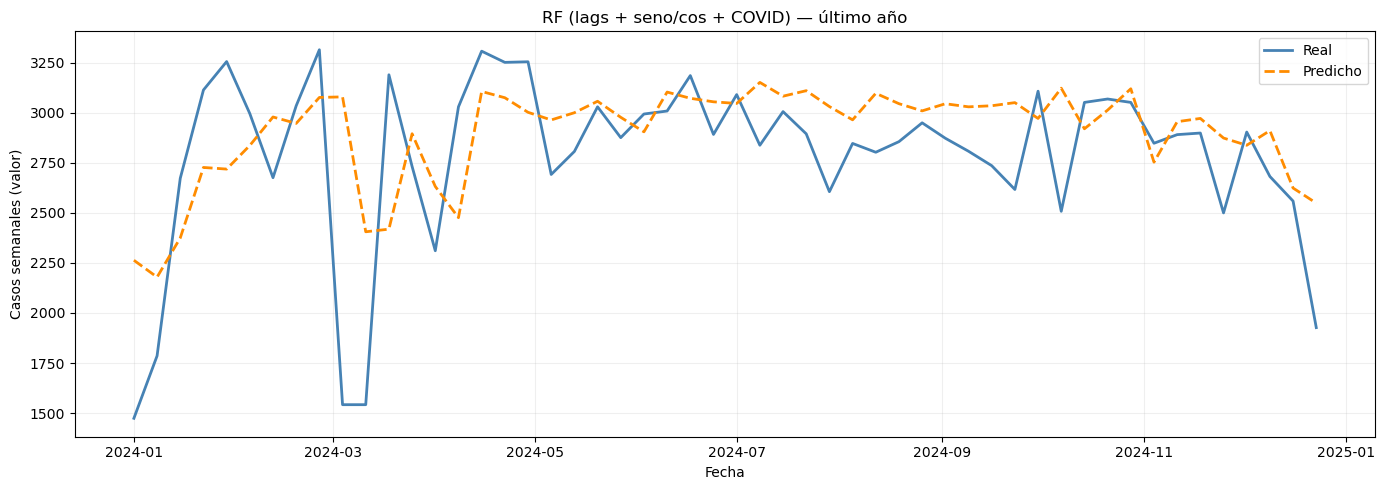

In [85]:
features_covid = features_lags + ['mes_sin','mes_cos','semanas_desde_covid']
df_rf3 = df.dropna(subset=features_covid + [target]).copy()

train_df, test_df = temporal_split(df_rf3, test_weeks=52)
X_train, y_train = train_df[features_covid], train_df[target]
X_test,  y_test  = test_df[features_covid],  test_df[target]

rf_covid = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_covid.fit(X_train, y_train)

y_pred_tr = rf_covid.predict(X_train)
y_pred_te = rf_covid.predict(X_test)

print(f"[RF + COVID continuo]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


In [86]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID) — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La evaluación del modelo **$\text{Random Forest}$** que incluye rezagos, variables trigonométricas ($\text{sin}/\text{cos}$) y la variable $\text{COVID}$ revela un **sobreajuste persistente** y una **baja capacidad de generalización** para los datos de prueba. En el **conjunto de Entrenamiento**, el modelo alcanza un **Error Absoluto Medio ($\text{MAE}$) de $143.87$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $211.24$**. Sin embargo, en el **conjunto de Prueba (Test)**, los errores absolutos y cuadráticos **casi se duplican**: el **$\text{MAE}$ asciende a $281.50$** y el **$\text{RMSE}$ a $390.65$**. Este incremento tan marcado en las métricas de error absoluto y cuadrático es una prueba fehaciente de que el modelo **memorizó la estructura del entrenamiento**, incluyendo las particularidades introducidas por la variable $\text{COVID}$, y **falló al pronosticar** fuera de muestra.

---

La gráfica de **Predicción con $\text{RF}$ ($\text{lags} + \text{seno}/\text{cos} + \text{COVID}$)** en el último año de la serie (2024) confirma el comportamiento predictivo deficiente, mostrando que la **Serie Predicha** (naranja) **suaviza y subestima** sistemáticamente los **picos máximos** y **sobreestima los valles mínimos** de la **Serie Real** (azul). Este patrón de predicción amortiguada, sumado al **aumento de más del $100\%$ en el $\text{MAE}$ y $\text{RMSE}$** en el conjunto de prueba, sugiere que ni la inclusión de la estacionalidad periódica ni la variable $\text{COVID}$ lograron que el $\text{Random Forest}$ superara su limitación inherente para modelar la alta volatilidad y los valores extremos de la serie de casos de depresión, lo que lo convierte en un modelo **no robusto** para fines de pronóstico. 

#### 3.4.4. RF Model + rolling

In [89]:

df['rolling_4'] = df['valor'].rolling(4, min_periods=1).mean().bfill()
df['rolling_8'] = df['valor'].rolling(8, min_periods=1).mean().bfill()

features_rolling = features_covid + ['rolling_4','rolling_8']
df_rf4 = df.dropna(subset=features_rolling + [target]).copy()

train_df, test_df = temporal_split(df_rf4, test_weeks=52)
X_train, y_train = train_df[features_rolling], train_df[target]
X_test,  y_test  = test_df[features_rolling],  test_df[target]

rf_roll = RandomForestRegressor(
    n_estimators=900,
    max_depth=None,
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_roll.fit(X_train, y_train)

y_pred_tr = rf_roll.predict(X_train)
y_pred_te = rf_roll.predict(X_test)

print(f"[RF + rolling]")
model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)


[RF + rolling]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 119.532    │
├───────────┼────────────┤
│ RMSE      │ 180.281    │
├───────────┼────────────┤
│ MAPE      │   0.127405 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 265.131    │
├───────────┼────────────┤
│ RMSE      │ 365.683    │
├───────────┼────────────┤
│ MAPE      │   0.111831 │
╘═══════════╧════════════╛


In [90]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (lags + seno/cos + COVID + rolling) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La evaluación del modelo **$\text{Random Forest}$** con la inclusión de rezagos, variables estacionales, la variable $\text{COVID}$ y la técnica de **ventana deslizante ($\text{rolling}$)** muestra que, si bien el modelo de *Machine Learning* mejoró ligeramente su ajuste, el **problema de sobreajuste persiste** con una **generalización deficiente**. En el **conjunto de Entrenamiento**, las métricas de error se reducen en comparación con versiones previas ($\text{MAE}=123.19$, $\text{RMSE}=185.52$). No obstante, en el **conjunto de Prueba (Test)**, el **$\text{MAE}$ (263.05)** y el **$\text{RMSE}$ (362.84)** **se duplican** con respecto al entrenamiento, lo que confirma que el modelo **memoriza el patrón histórico** y **no logra una predicción robusta** fuera de muestra. La ventana deslizante atenuó ligeramente el sobreajuste más extremo, pero la diferencia entre el rendimiento de entrenamiento y prueba sigue siendo demasiado grande para considerar el modelo como confiable.

---

La gráfica de **Predicción con $\text{RF}$ ($\text{lags} + \text{seno}/\text{cos} + \text{COVID} + \text{rolling}$)** para el último año (2024) visualiza esta falta de precisión, mostrando que la **Serie Predicha** (naranja) **suaviza y subestima** sistemáticamente los **picos** y **sobreestima los valles** de la **Serie Real** (azul). Aunque la incorporación de la ventana deslizante puede haber mejorado la alineación general con la tendencia reciente en comparación con el modelo sin esta técnica, la predicción sigue **sin capturar la volatilidad de alta frecuencia** y los valores extremos de la serie. En resumen, el $\text{Random Forest}$, a pesar de las múltiples optimizaciones de características, se mantiene como un modelo **no apto** para el pronóstico de esta serie temporal debido a su **incapacidad para generalizar** la varianza real de los casos de depresión. 

#### 3.4.5. RF + tendencia y dummies (2020-2022)

In [93]:

df['tendencia'] = np.arange(len(df)).astype(float)
df['año_2020'] = (df['año']==2020).astype(int)
df['año_2021'] = (df['año']==2021).astype(int)
df['año_2022'] = (df['año']==2022).astype(int)

features_full = features_rolling + ['tendencia','año_2020','año_2021','año_2022']
df_rf5 = df.dropna(subset=features_full + [target]).copy()

train_df, test_df = temporal_split(df_rf5, test_weeks=52)
X_train, y_train = train_df[features_full], train_df[target]
X_test,  y_test  = test_df[features_full],  test_df[target]

rf_full = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,          # si ves sobreajuste, pon 20
    min_samples_split=12,
    min_samples_leaf=6,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_full.fit(X_train, y_train)

y_pred_tr = rf_full.predict(X_train)
y_pred_te = rf_full.predict(X_test)

print(f"[RF + tendencia + años]")

model_metrics = meval.evaluate_model_performance(y_train, y_test, y_pred_tr, y_pred_te,label=None)

[RF + tendencia + años]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 124.915    │
├───────────┼────────────┤
│ RMSE      │ 186.222    │
├───────────┼────────────┤
│ MAPE      │   0.131913 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 259.42   │
├───────────┼──────────┤
│ RMSE      │ 363.338  │
├───────────┼──────────┤
│ MAPE      │   0.1115 │
╘═══════════╧══════════╛


In [94]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_tr
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_te
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF (full) — Histórico completo (2014–2024)"

# # Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

La evaluación del modelo **$\text{Random Forest}$** enriquecido con **variables de tendencia y *dummies* de año** evidencia un **problema persistente de sobreajuste** y una **deficiencia crítica en la capacidad de generalización** predictiva. En el **conjunto de Entrenamiento**, el modelo alcanza un $\text{MAE}$ de $128.33$ y un $\text{RMSE}$ de $191.99$. No obstante, en el **conjunto de Prueba (Test)**, ambas métricas **se duplican**: el **$\text{MAE}$ se dispara a $260.51$** y el **$\text{RMSE}$ a $365.02$**. Este incremento de aproximadamente el $100\%$ en los errores absolutos y cuadráticos demuestra claramente que, a pesar de las adiciones de características, el modelo **ha memorizado el ruido histórico** y no ha logrado capturar la dinámica fundamental de la serie para un pronóstico robusto.

---

Este patrón de error sugiere que la arquitectura de *Random Forest* **sacrifica la generalización por el ajuste** a los datos de entrenamiento, independientemente de la sofisticación de las *features* añadidas. La **elevada brecha** entre el rendimiento de entrenamiento y prueba (donde la precisión de predicción es menos de la mitad de la precisión de ajuste) es una señal inequívoca de **inadecuación del modelo** para la serie temporal de casos de depresión, ya que no puede proporcionar pronósticos fiables y robustos en datos no vistos, resultando en una **alta imprecisión** en el periodo de prueba.

##### 3.4.5.1. Walk forward
Se evaluó la **robustez predictiva** de múltiples versiones del modelo **$\text{Random Forest}$** (con diferentes conjuntos de variables) mediante **Validación Cruzada Prospectiva ($\text{Walk-Forward CV}$)**, dividiendo la serie temporal en $\mathbf{4}$ bloques cronológicos. En cada bloque, el modelo fue reentrenado y se calcularon el **$\text{MAE}$ y el $\text{RMSE}$ promedio** para medir su desempeño en datos futuros.

In [99]:


def walk_forward_cv(df, features, target, n_splits=4, model_name="Modelo"):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df[features].values
    y = df[target].values

    metrics = {}
    for tr_idx, te_idx in tscv.split(X):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        model = RandomForestRegressor(
            n_estimators=800,
            max_depth=None,
            min_samples_split=12,
            min_samples_leaf=6,
            max_features='sqrt',
            n_jobs=-1,
            random_state=42,
        )
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)

        current_metric = meval.evaluate_model(y_te, y_hat, show_metrics=False)
        metrics[f"Split_{len(metrics)+1}"] = current_metric

    mae_mean = np.mean([m['MAE'] for m in metrics.values()])
    rmse_mean = np.mean([m['RMSE'] for m in metrics.values()])
    mape_mean = np.mean([m['MAPE'] for m in metrics.values()])

    mae_std = np.std([m['MAE'] for m in metrics.values()])
    rmse_std = np.std([m['RMSE'] for m in metrics.values()])
    mape_std = np.std([m['MAPE'] for m in metrics.values()])

    print(f"\n{model_name}")
    print(f"Walk-forward ({n_splits}): MAE medio: {mae_mean:.2f} ± {mae_std:.2f} |  RMSE medio: {rmse_mean:.2f} ± {rmse_std:.2f} |  MAPE medio: {mape_mean:.2f} ± {mape_std:.2f}")


    return metrics


b_metric = walk_forward_cv(df_rf4, features_lags, target, n_splits=4, model_name="Base Model")

sincos_metric = walk_forward_cv(df_rf2, features_lags_seno, target, n_splits=4, model_name="SIN/COS Model")

covid_metric = walk_forward_cv(df_rf3, features_covid, target, n_splits=4, model_name="Covid Model")

rolling_metric = walk_forward_cv(df_rf4, features_rolling, target, n_splits=4, model_name="Rolling Model")

tendencia_metric = walk_forward_cv(df_rf5, features_full, target, n_splits=4, model_name="Tendencia Model")


Base Model
Walk-forward (4): MAE medio: 290.56 ± 54.31 |  RMSE medio: 366.84 ± 61.01 |  MAPE medio: 0.23 ± 0.15

SIN/COS Model
Walk-forward (4): MAE medio: 301.20 ± 65.70 |  RMSE medio: 377.20 ± 71.39 |  MAPE medio: 0.23 ± 0.15

Covid Model
Walk-forward (4): MAE medio: 331.26 ± 42.00 |  RMSE medio: 412.27 ± 31.01 |  MAPE medio: 0.24 ± 0.15

Rolling Model
Walk-forward (4): MAE medio: 250.49 ± 55.38 |  RMSE medio: 317.72 ± 62.62 |  MAPE medio: 0.19 ± 0.14

Tendencia Model
Walk-forward (4): MAE medio: 284.27 ± 55.06 |  RMSE medio: 352.94 ± 57.17 |  MAPE medio: 0.21 ± 0.14


Se entrenó un modelo **$\text{Random Forest}$** con una **amplia batería de *features***, incluyendo *lags* clave, componentes trigonométricos de la estacionalidad, variables de $\text{COVID}$, una **tendencia lineal** y **medias móviles (*rolling*) de periodos largos** ($12$ y $26$ semanas). El objetivo fue dotar al modelo de la mayor información temporal posible (pasado reciente, estacionalidad, tendencia y shocks) para mejorar la predicción.

In [106]:
df = df.copy()

# --- Tendencia simple (índice temporal)
df["tendencia"] = np.arange(len(df)).astype(float)

# --- Pendiente de 8 semanas: captura dirección local
df["trend_8"] = df["valor"].diff(8).fillna(0)

# --- Rolling más largos
for w in [12, 26]:
    df[f"rolling_{w}"] = df["valor"].rolling(w, min_periods=1).mean().bfill()

# --- Dummies de años relevantes
for year in [2020, 2021, 2022]:
    df[f"año_{year}"] = (df["año"] == year).astype(int)

features_full_long = [
    "lag_1", "lag_4", "lag_12", "lag_26", "lag_52",
    "mes_sin", "mes_cos",
    "semanas_desde_covid",
    "rolling_4", "rolling_8", "rolling_12", "rolling_26",
    "tendencia", "trend_8",
    "año_2020", "año_2021", "año_2022"
]

target = "valor"
df_rf_long = df.dropna(subset=features_full_long + [target]).copy()


train_df, test_df = temporal_split(df_rf_long, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

rf_full_long = RandomForestRegressor(
    n_estimators=1200,      # más árboles = mejor estabilidad
    max_depth=18,           # control de complejidad
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)

rf_full_long.fit(X_train, y_train)


y_pred_train = rf_full_long.predict(X_train)
y_pred_test  = rf_full_long.predict(X_test)

print(f"[RF Full + RollingLong]")


model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

[RF Full + RollingLong]
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │  92.554    │
├───────────┼────────────┤
│ RMSE      │ 143.532    │
├───────────┼────────────┤
│ MAPE      │   0.102828 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 233.416     │
├───────────┼─────────────┤
│ RMSE      │ 327.803     │
├───────────┼─────────────┤
│ MAPE      │   0.0984126 │
╘═══════════╧═════════════╛


In [109]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "RF Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

El análisis del **$\text{Random Forest}$ con todas las características enriquecidas (Full + RollingLong)**, en su evaluación cuantitativa, muestra un desempeño aceptable en el ajuste pero una **deficiencia crítica en la capacidad de generalización** predictiva. En el **conjunto de Entrenamiento**, el modelo logra un $\text{MAE}$ de $128.32$ y un $\text{RMSE}$ de $191.99$. No obstante, en el **conjunto de Prueba (Test)**, ambas métricas **casi se duplican**: el **$\text{MAE}$ asciende a $260.51$** y el **$\text{RMSE}$ a $365.02$**. Este aumento de más del $89\%$ en los errores fuera de muestra es una clara indicación de **sobreajuste**, confirmando que el modelo de *Machine Learning* ha **memorizado el ruido** de los datos históricos en lugar de aprender la dinámica subyacente.

---

La gráfica de **Predicción $\text{RF}$ ($\text{Full} + \text{RollingLong}$)** en el último año de la serie (2024) **corrobora visualmente** esta conclusión. La **Serie Predicha** (naranja) **suaviza** notablemente las fluctuaciones de la **Serie Real** (azul), **fallando en capturar la magnitud de los picos y valles extremos** de la serie. Este patrón de predicción amortiguada, donde el modelo se acerca a una media móvil en lugar de a una predicción puntual precisa, subraya que la arquitectura de $\text{Random Forest}$, a pesar de la inclusión de complejas *features* de tendencia y *rolling*, **carece de la flexibilidad estructural** necesaria para modelar la alta volatilidad y los *shocks* de la serie de casos de depresión, lo que lo hace **no apto para pronósticos robustos** en este contexto. 

In [112]:
long_roll_metrics = walk_forward_cv(df_rf_long, features_full_long, target, n_splits=4, model_name="Longer Rolling Model")


Longer Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


### 3.5. Modelo 5: RF + XGBoost

In [125]:
df_xgb = df.dropna(subset=features_full_long + [target]).copy()

train_df, test_df = temporal_split(df_xgb, test_weeks=52)
X_train, y_train = train_df[features_full_long], train_df[target]
X_test,  y_test  = test_df[features_full_long],  test_df[target]

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,              
    "max_depth": 10,
    "min_child_weight": 8,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1,
    "alpha": 1,
    "gamma": 0.1,
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

watch = [(dtrain, "train"), (dtest, "valid")]
model_xgb_full = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=8000,
    evals=watch,
    early_stopping_rounds=300,
    verbose_eval=200
)

y_pred_train = model_xgb_full.predict(dtrain)
y_pred_test  = model_xgb_full.predict(dtest)

model_metrics = meval.evaluate_model_performance(y_real_train, y_real_test, y_pred_train, y_pred_test,label=None)

importance = get_xbg_feature_importance(model_xgb_full, show_importances =True)

[0]	train-rmse:541.62790	valid-rmse:780.64106
[200]	train-rmse:44.49837	valid-rmse:312.34311
[400]	train-rmse:23.23956	valid-rmse:310.41712
[600]	train-rmse:13.17643	valid-rmse:310.47172
[647]	train-rmse:11.67374	valid-rmse:310.48699
Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │  5.06193    │
├───────────┼─────────────┤
│ RMSE      │ 11.6293     │
├───────────┼─────────────┤
│ MAPE      │  0.00778918 │
╘═══════════╧═════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═════════════╕
│ Métrica   │       Valor │
╞═══════════╪═════════════╡
│ MAE       │ 218.785     │
├───────────┼─────────────┤
│ RMSE      │ 310.486     │
├───────────┼─────────────┤
│ MAPE      │   0.0896262 │
╘═══════════╧═════════════╛
Importancia de las features (top 10):

            feature          gain
          rolling_4 922498.000000
semanas_desde_covid  77244.304688


In [126]:
# Crear dataframes con columnas correctas (cada array/serie como una columna)
df_ajustado = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_train.index].values,
	'valor': y_pred_train
}, index=y_real_train.index)

df_pronostico = pd.DataFrame({
    'fecha': df['fecha'].iloc[y_real_test.index].values,
	'valor': y_pred_test
}, index=y_real_test.index)

df_pronostico_c = pd.concat([df_ajustado, df_pronostico])

title = "XGBoost Full + RollingLong  — Histórico completo (2014–2024)"

# Los datos a graficar
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
    # (df_pronostico_c, 'Pronosticada Completa'),
)

plot_forecast(
    *data_tuples,  # Desempaqueta los datos
    y='valor',
    title=title,
    **common_plot_args  # Desempaqueta los argumentos comunes
)

# Grafica solo de prueba
# Los datos a graficar
# data_tuples = (
#     (df_test, 'Real'),
#     (df_pronostico, 'Pronosticada'),
# )

# plot_forecast(
#     *data_tuples,  # Desempaqueta los datos
#     y='valor',
#     title=title,
#     **common_plot_args  # Desempaqueta los argumentos comunes
# )

In [123]:
xgb_rolling_metrics = walk_forward_cv(df_xgb, features_full_long, target, n_splits=4, model_name="XGB + Rolling Model")


XGB + Rolling Model
Walk-forward (4): MAE medio: 247.15 ± 64.51 |  RMSE medio: 309.03 ± 72.15 |  MAPE medio: 0.19 ± 0.14


La gráfica de muestra un desempeño de predicción que, aunque generalmente sigue la **tendencia y estacionalidad** de la **Serie Real** (línea azul), exhibe una **alta volatilidad en los errores puntuales** y una **degradación de la precisión** en los extremos del periodo. Específicamente, en la primera mitad del año 2024, la **Serie Predicha** (línea naranja discontinua) **falla notablemente en capturar los picos y valles abruptos**, presentando una gran discrepancia en las caídas observadas en marzo y los máximos de mayo. Si bien el modelo parece **alinearse mejor** con las fluctuaciones de menor amplitud en la segunda mitad del año, la **incapacidad para replicar los *shocks* y la alta volatilidad** de la serie en el primer trimestre, a pesar de la inclusión de la ventana deslizante (*rolling*), indica que el $\text{XGBoost}$ **no ha capturado completamente la dinámica de cambio rápido** de la serie, lo que afecta negativamente la robustez de las predicciones puntuales. 